In [34]:
print('Radha!')

Radha!


In [35]:
from typing import TypedDict

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [36]:
load_dotenv()
llm = ChatOpenAI()

In [37]:
class StartupState(TypedDict):
    company: str

    products: str
    competitors: str
    risks: str

    final_report: str

In [38]:
def product_agent(state):
    company = state["company"]

    response = llm.invoke(
        f"""
        Analyze the products and services of {company}.
        """
    )

    return {
        "products": response.content
    }


In [39]:
def competitor_agent(state):
    company = state["company"]

    response = llm.invoke(
        f"""
        Analyze the competitors of {company}.
        """
    )

    return {
        "competitors": response.content
    }

In [40]:
def risk_agent(state):
    company = state["company"]

    response = llm.invoke(
        f"""
        Analyze business risks of {company}.
        """
    )

    return {
        "risks": response.content
    }

In [41]:
def report_generator(state):

    report = f"""
# Startup Analysis

## Products
{state['products']}

## Competitors
{state['competitors']}

## Risks
{state['risks']}
"""

    return {
        "final_report": report
    }

In [42]:
builder = StateGraph(StartupState)

builder.add_node("products", product_agent)
builder.add_node("competitors", competitor_agent)
builder.add_node("risks", risk_agent)

builder.add_node("report", report_generator)

In [43]:
builder.add_edge(START, "products")
builder.add_edge(START, "competitors")
builder.add_edge(START, "risks")

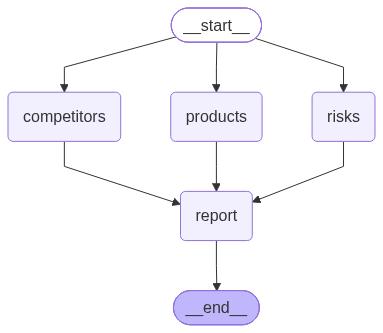

In [44]:
builder.add_edge("products", "report")
builder.add_edge("competitors", "report")
builder.add_edge("risks", "report")

builder.add_edge("report", END)

graph = builder.compile()

graph

In [45]:
result = graph.invoke({
    "company": "OpenAI"
})

print(result["final_report"])


# Startup Analysis

## Products
OpenAI offers a range of products and services that leverage advanced artificial intelligence technologies to solve complex problems and drive innovation. Some of the key offerings of OpenAI include:

1. GPT-3 (Generative Pre-trained Transformer 3): GPT-3 is a state-of-the-art language model that can generate human-like text based on given prompts. It can be used for a wide range of applications including natural language processing, content generation, and more.

2. DALL-E: DALL-E is another AI model developed by OpenAI that can generate images from textual descriptions. It can create unique and artistic images based on user input, enabling creative applications in design, art, and visual storytelling.

3. OpenAI API: OpenAI offers an API that allows developers to access and integrate their AI models into their applications. This enables businesses and individuals to leverage advanced AI capabilities without needing to build and train their own models.

In [46]:
results = graph.stream({
    "company": "OpenAI"
})

for result in results:
    print(result)

{'competitors': {'competitors': 'OpenAI has several competitors in the field of artificial intelligence and machine learning. Some of the key competitors include:\n\n1. Google DeepMind: DeepMind is a British AI company acquired by Google in 2014. They are known for their research in deep reinforcement learning and artificial general intelligence.\n\n2. Microsoft Research: Microsoft has a strong research division focused on AI, with projects such as the Azure AI platform and the Microsoft Cognitive Services.\n\n3. IBM Watson: IBM Watson is a cognitive computing platform that uses natural language processing and machine learning to provide insights from large amounts of data.\n\n4. Facebook AI Research (FAIR): Facebook has a dedicated research division focused on AI and machine learning, developing technologies such as object recognition and language translation.\n\n5. Tesla: While primarily known for their electric cars, Tesla also has a strong focus on AI and autonomous driving technol

In [47]:
results = graph.stream({
    "company": "OpenAI"
})

for result in results:
    for key, values in result.items():
        print (key   ,":",  values)

products : {'products': "OpenAI offers a range of products and services that focus on artificial intelligence research and development. Some of their key offerings include:\n\n1. GPT-3 (Generative Pre-trained Transformer 3): GPT-3 is a cutting-edge language model that has the ability to generate human-like text based on the input it receives. It is widely used for natural language processing tasks such as text generation, summarization, and translation.\n\n2. OpenAI API: OpenAI offers an API that allows developers to access the power of GPT-3 and integrate it into their own applications and software. This API enables users to leverage the capabilities of GPT-3 without needing to build their own language models from scratch.\n\n3. OpenAI Codex: Codex is a language model developed by OpenAI that is specifically designed for programming tasks. It can understand and generate code in multiple programming languages, making it a useful tool for developers looking to automate coding tasks or g

In [48]:
results = graph.stream({
    "company": "OpenAI"
})

for result in results:
    if 'report' in result:
        content = result["report"]["final_report"]
        print(content)


# Startup Analysis

## Products
OpenAI offers a range of products and services focused on advancing artificial intelligence research and development. Some of their key offerings include:

1. GPT-3: One of OpenAI's most famous products is the GPT-3 (Generative Pre-trained Transformer 3) language model. GPT-3 is a powerful natural language processing tool that can generate human-like text based on input prompts. It has applications in various fields, including content generation, chatbots, customer support, and more.

2. OpenAI API: OpenAI provides an API (Application Programming Interface) that allows developers to access and use the capabilities of GPT-3 in their own applications. This allows businesses to leverage the power of the language model without having to build their own AI technology from scratch.

3. Research: OpenAI also conducts cutting-edge research in artificial intelligence, with a focus on developing advanced algorithms and techniques for improving machine learning mo